# Example-05: Phase estimation

In [1]:
# Import

import numpy
import torch
import yaml

import sys
sys.path.append('..')

from harmonica.util import mod
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter
from harmonica.decomposition import Decomposition

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())

True


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

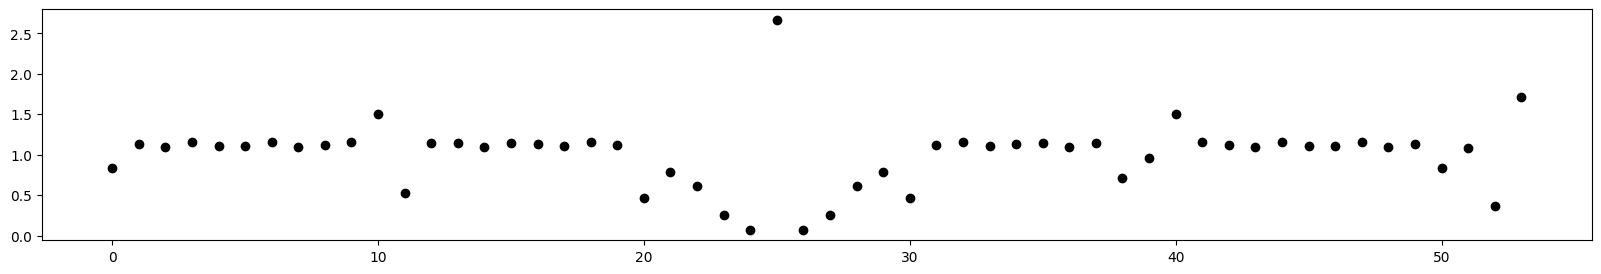

In [3]:
# Load model phase advance data

with open('../config.yaml', 'r') as stream:
    config = yaml.safe_load(stream)
    config = {key: config[key] for key in sorted(config.keys(), key=lambda name: config[name]['TIME'])}

total = config['TAIL']['FX']
model = torch.tensor([value['FX'] for key, value in config.items() if value['TYPE'] == 'MONITOR'], dtype=dtype, device=device)

# Plot adjacent phase advance

model, _ = Decomposition.phase_adjacent(total, model)
plt.figure(figsize=(20, 3))
plt.scatter(range(54), model.cpu().numpy(), color='black')
plt.show()

In [4]:
# Estimate reference parameters

# Set window

length = 4096
w = Window(length, 'cosine_window', 5.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Estimate frequency

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency

# Estimate amplitude for given frequency

h = Decomposition(d)
result, _ = h.harmonic_sum(frequency, w.window, d.data)
_, _, amplitude, phase = result.T

# Check maximum reconstruction error

result = []
for a, b in zip(amplitude, phase):
    result.append(Data.make_harmonic(length, frequency, a=a, b=b, dtype=dtype, device=device))
result = torch.stack(result)
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}, error={(d.data - result).abs().max().item():12.9}')

frequency= 0.536883099, spread=1.37250775e-16, error=2.56151871e-13


In [5]:
# Real TbT data length is limited by decoherence
# In this example 1024 turns are used for frequency estimation and only 512 for phase

# Set window

length = 1024
w = Window(length, 'cosine_window', 1.0, dtype=dtype, device=device)

# Load data

d = Data.from_file(54, w, '../virtual_tbt.npy')

# Add random noise

n = 1.0E-6*(25.0 + 75.0*torch.rand(54, dtype=dtype, device=device))
d.add_noise(n)
d.data.copy_(d.work)

# Estimate frequency (average over signals)

f = Frequency(d)
d.window_remove_mean()
d.window_apply()
f('parabola')
d.reset()
frequency, spread = f.frequency.mean(), f.frequency.std()
frequency = 1.0 - frequency
print(f'frequency={frequency.item():12.9}, spread={spread.item():12.9}')

frequency= 0.536883013, spread=1.1499505e-06


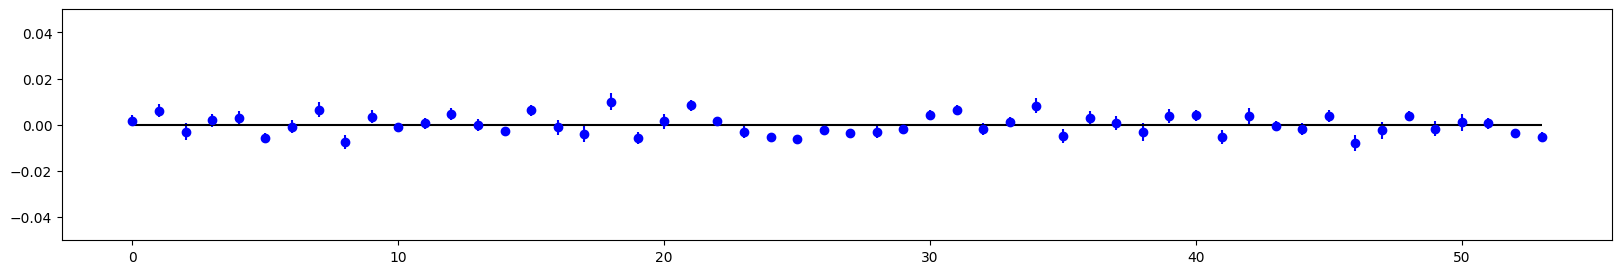

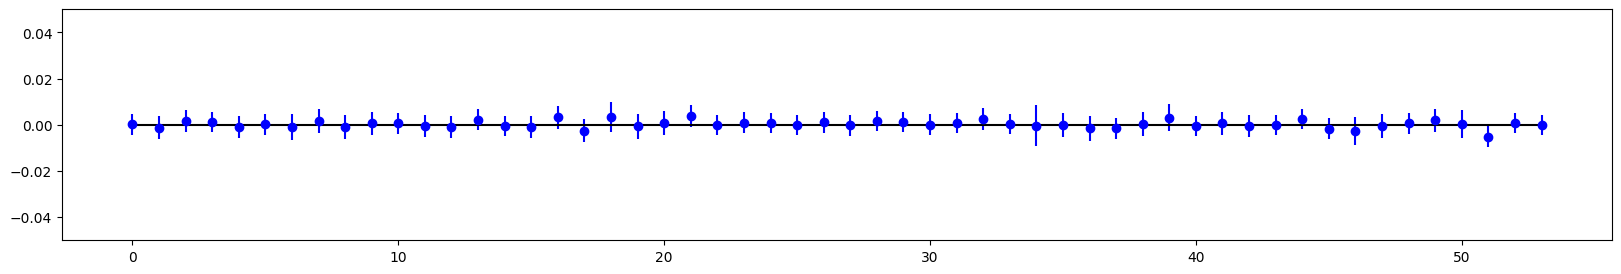

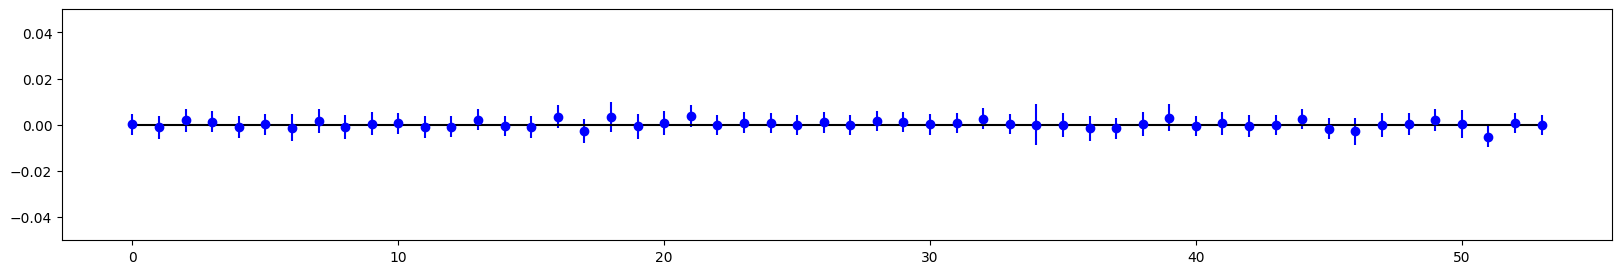

tensor(1.964897889357e-01, dtype=torch.float64)
tensor(6.468313110960e-02, dtype=torch.float64)
tensor(6.479449715026e-02, dtype=torch.float64)


In [6]:
# Estimate phase

dec = Decomposition(d)
out1, err1, _ = dec.harmonic_phase(frequency, length=512, order=0.0, error=True, sigma_frequency=spread)
out2, err2, _ = dec.harmonic_phase(frequency, length=256, order=0.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, clean=False, method='none')
out3, err3, _ = dec.harmonic_phase(frequency, length=256, order=0.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, clean=False, method='noise')

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out1 - phase).cpu().numpy(), yerr=err1.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out2 - phase).cpu().numpy(), yerr=err2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out3 - phase).cpu().numpy(), yerr=err3.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

print((out1 - phase).abs().sum())
print((out2 - phase).abs().sum())
print((out3 - phase).abs().sum())

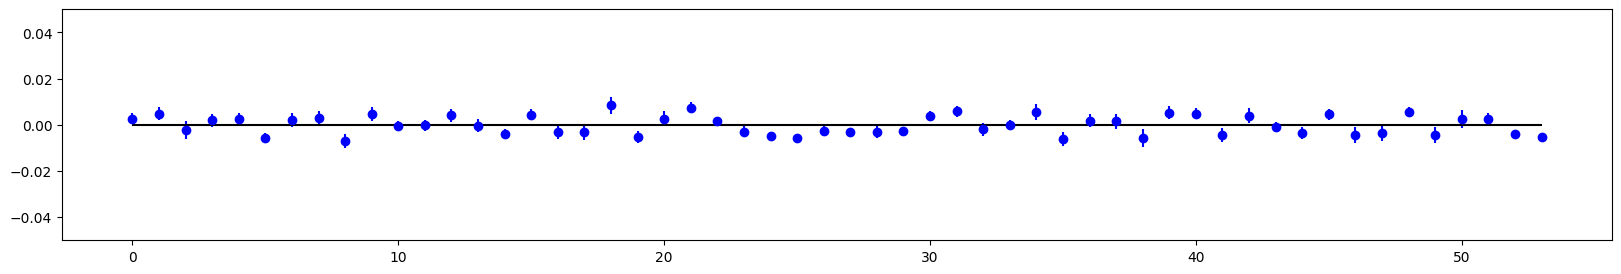

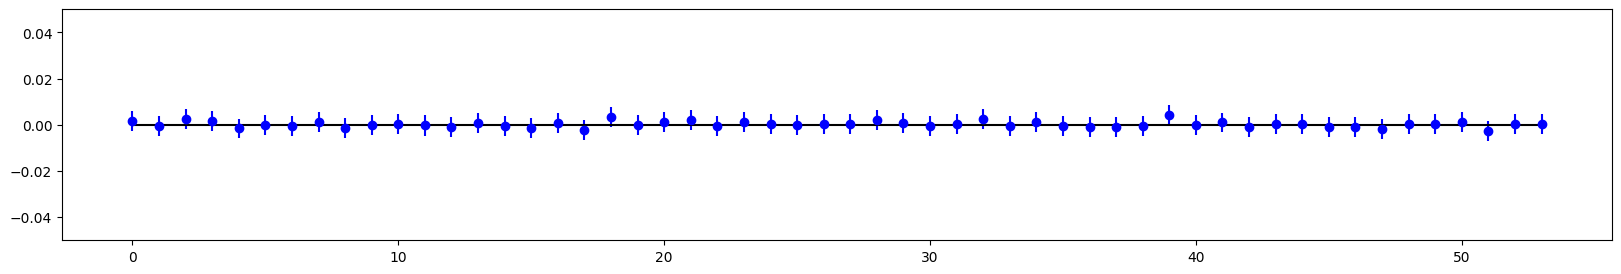

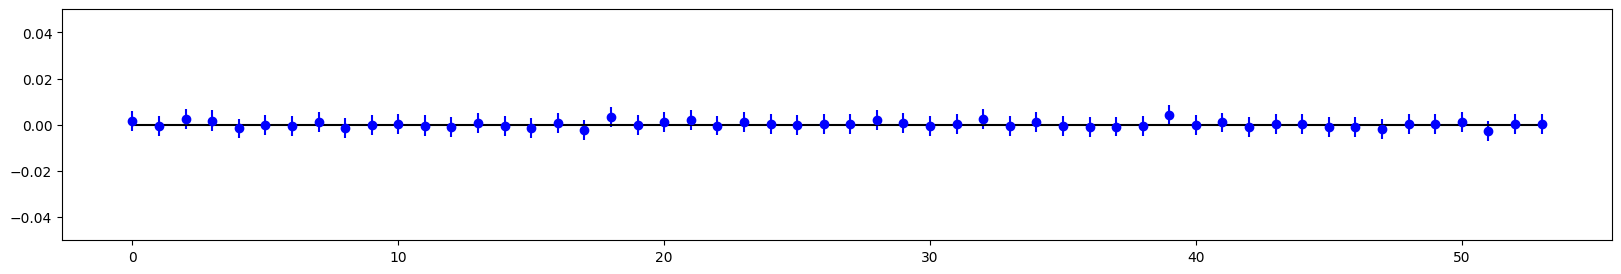

tensor(1.992010788797e-01, dtype=torch.float64)
tensor(5.587386483783e-02, dtype=torch.float64)
tensor(5.603022061181e-02, dtype=torch.float64)


In [7]:
# Estimate phase (filter)

flt = Filter(d)
flt.filter_svd(rank=2)
flt.filter_hankel(rank=2, random=True, buffer=16, count=16)
out1, err1, _ = dec.harmonic_phase(frequency, length=512, order=0.0, error=True, sigma_frequency=spread)
out2, err2, _ = dec.harmonic_phase(frequency, length=256, order=0.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, clean=False, method='none')
out3, err3, _ = dec.harmonic_phase(frequency, length=256, order=0.0, error=True, sigma_frequency=spread, shift=True, count=64, step=8, clean=False, method='noise')

# Compare results

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out1 - phase).cpu().numpy(), yerr=err1.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out2 - phase).cpu().numpy(), yerr=err2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (out3 - phase).cpu().numpy(), yerr=err3.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

print((out1 - phase).abs().sum())
print((out2 - phase).abs().sum())
print((out3 - phase).abs().sum())

d.reset()

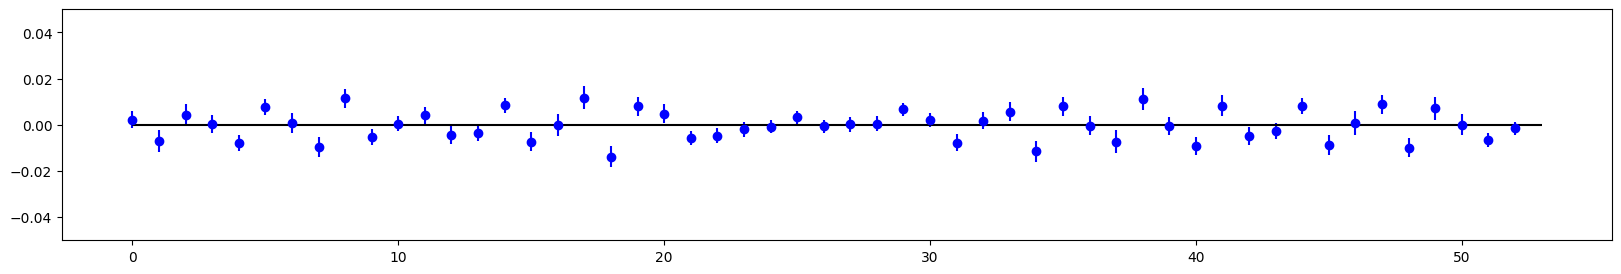

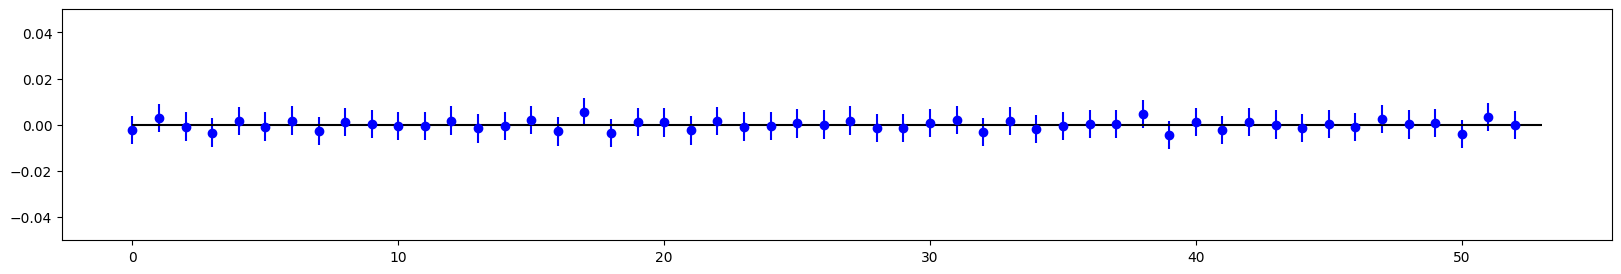

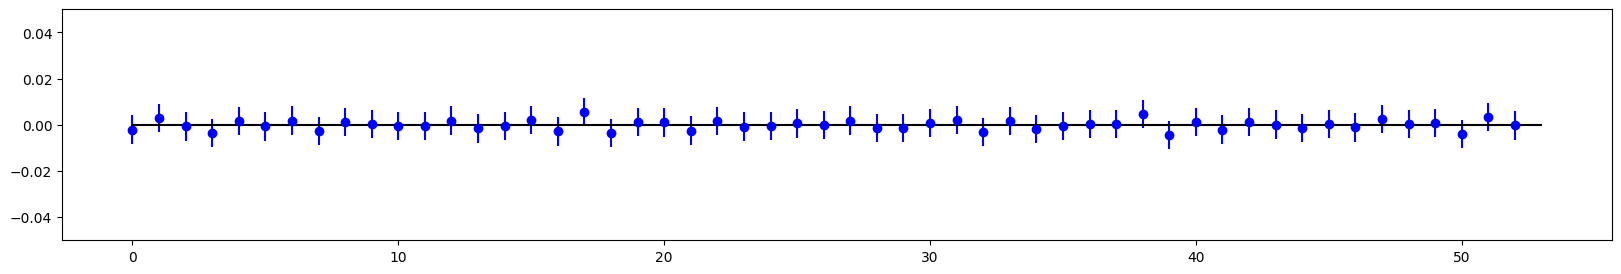

tensor(9.123930520356e-01, dtype=torch.float64)
tensor(7.268877958956e-01, dtype=torch.float64)
tensor(7.270459094813e-01, dtype=torch.float64)


In [8]:
# Compute and compare phase advance for the last case

add1, std1 = Decomposition.phase_adjacent(frequency, out1, error=True, sigma_frequency=spread, sigma_phase=err1)
add2, std2 = Decomposition.phase_adjacent(frequency, out2, error=True, sigma_frequency=spread, sigma_phase=err2)
add3, std3 = Decomposition.phase_adjacent(frequency, out3, error=True, sigma_frequency=spread, sigma_phase=err3)

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (add1 - model).cpu().numpy(), yerr=std1.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (add2 - model).cpu().numpy(), yerr=std2.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

plt.figure(figsize=(20, 3))
plt.errorbar(range(54), (add3 - model).cpu().numpy(), yerr=std3.cpu().numpy(), fmt=' ', marker='o', color='blue')
plt.hlines(0, 0, 53, colors='black')
plt.ylim(-5.0E-2, +5.0E-2)
plt.show()

print((add1 - model).abs().sum())
print((add2 - model).abs().sum())
print((add3 - model).abs().sum())

In [9]:
# Compute phase advance using SVD

u, s, vh = torch.linalg.svd(d.data, full_matrices=False)
out4 = torch.atan2(s[1]*u[:, 1], s[0]*u[:, 0])
add4, _ =  Decomposition.phase_adjacent(frequency, out4, error=False)
print((add4 - model).abs().sum())

add4 = Decomposition.svd_advance(frequency, d.data)
print((add4 - model).abs().sum())

tensor(7.731425955760e-01, dtype=torch.float64)
tensor(7.731425955760e-01, dtype=torch.float64)


In [10]:
# Compute phase advance using ICA
# Note, order of components is not guarantied, use model to infere order

from sklearn.decomposition import FastICA
ica = FastICA(n_components=2, whiten='unit-variance')
_ = ica.fit_transform(d.data.T)
out5 = torch.tensor(ica.mixing_, dtype=dtype, device=device).T
out5 = torch.atan2(out5[0], out5[1])
add5, _ = Decomposition.phase_adjacent(frequency, out5, error=False)
print((add5 - model).abs().sum())

add5 = Decomposition.ica_advance(frequency, d.data, model, whiten='unit-variance')
print((add5 - model).abs().sum())

tensor(7.731533089149e-01, dtype=torch.float64)
tensor(7.731533089149e-01, dtype=torch.float64)
